In [20]:
import pandas as pd
df=pd.read_csv("food_delivery_data.csv")
df.head()

,OrderID,OrderDate,OrderTime,Location,FoodItem,Quantity,Price,CustomerRating
0,1,24-11-2025,03:01,Madurai,Paneer Butter Masala,3,182.85,3.3
1,2,13-12-2025,23:57,Madurai,Pasta,1,328.01,3.1
2,3,22-04-2025,07:32,Tirunelveli,Sandwich,1,315.72,4.4
3,4,07-10-2025,13:14,Chennai,Noodles,5,196.84,4.7
4,5,24-12-2025,13:21,Madurai,Idli,2,170.43,4.5


In [21]:
import pandas as pd
df=pd.read_csv("food_delivery_data.csv")
df.tail()

,OrderID,OrderDate,OrderTime,Location,FoodItem,Quantity,Price,CustomerRating
995,996,18-02-2025,19:48,Tirunelveli,Burger,5,215.49,3.6
996,997,04-06-2025,08:43,Chennai,Paneer Butter Masala,3,120.25,4.2
997,998,07-01-2025,04:33,Chennai,Idli,3,407.10,3.8
998,999,22-02-2025,06:09,Salem,Pasta,2,429.26,4.6
999,1000,11-11-2025,22:53,Madurai,Pasta,5,379.27,4.4


In [22]:
import pandas as pd
df=pd.read_csv("food_delivery_data.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         1000 non-null   int64  
 1   OrderDate       1000 non-null   object 
 2   OrderTime       1000 non-null   object 
 3   Location        1000 non-null   object 
 4   FoodItem        1000 non-null   object 
 5   Quantity        1000 non-null   int64  
 6   Price           1000 non-null   float64
 7   CustomerRating  1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [23]:
import pandas as pd
df=pd.read_csv("food_delivery_data.csv")
df.describe()

,OrderID,Quantity,Price,CustomerRating
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.030000,282.255370,4.028100
std,288.819436,1.416724,122.110791,0.565332
min,1.000000,1.000000,80.460000,3.000000
25%,250.750000,2.000000,178.437500,3.600000
50%,500.500000,3.000000,275.140000,4.000000
75%,750.250000,4.000000,384.572500,4.500000
max,1000.000000,5.000000,499.830000,5.000000


In [24]:
import pandas as pd
df=pd.read_csv("food_delivery_data.csv")
df.columns

Index(['OrderID', 'OrderDate', 'OrderTime', 'Location', 'FoodItem', 'Quantity',
       'Price', 'CustomerRating'],
      dtype='object')

In [ ]:
total_revenue = df['Price'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 282255.37


In [ ]:
df['OrderTime'] = pd.to_datetime(df['OrderTime'], format='%H:%M:%S')
peak_order_times = df.groupby(df['OrderTime'].dt.hour)['OrderID'].count()
print(peak_order_times)

OrderTime
0     36
1     35
2     34
3     45
4     49
5     44
6     41
7     33
8     35
9     43
10    46
11    29
12    40
13    50
14    41
15    44
16    35
17    51
18    47
19    51
20    46
21    41
22    43
23    41
Name: OrderID, dtype: int64


In [ ]:
popular_dishes = df['FoodItem'].value_counts()
print(popular_dishes.head(10))

FoodItem
Pasta                   103
Noodles                  97
Pizza                    90
Burger                   87
Chicken 65               83
Idli                     83
Paneer Butter Masala     81
Biryani                  80
Parotta                  80
Fried Rice               73
Name: count, dtype: int64


In [ ]:

location_sales = df.groupby('Location')['Price'].sum().sort_values(ascending=False)
print(location_sales)


Location
Salem          49156.67
Tirunelveli    49077.68
Trichy         48746.23
Madurai        45958.04
Coimbatore     45319.34
Chennai        43997.41
Name: Price, dtype: float64


In [ ]:

rating_analysis = df['CustomerRating'].describe()
print(rating_analysis)

count    1000.000000
mean        4.028100
std         0.565332
min         3.000000
25%         3.600000
50%         4.000000
75%         4.500000
max         5.000000
Name: CustomerRating, dtype: float64


In [ ]:
avg_order_value = (df['Quantity'] * df['Price']).mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 860.1335300000001


In [ ]:
highest_selling_item = df.groupby('FoodItem')['Quantity'].sum().idxmax()
print("Highest Selling Food Item:", highest_selling_item)

Highest Selling Food Item: Pasta


In [ ]:
daily_sales = df.groupby('OrderDate').apply(lambda x: (x['Quantity'] * x['Price']).sum(), include_groups=False)
print(daily_sales)

OrderDate
01-01-2025    1994.01
01-02-2025    3069.73
01-03-2025    4706.66
01-04-2025    3878.74
01-05-2025    2419.80
               ...   
31-03-2025    2736.20
31-05-2025    2496.20
31-07-2025    5831.64
31-10-2025    1670.65
31-12-2025    2307.68
Length: 343, dtype: float64


In [19]:
total_quantity = df['Quantity'].sum()
print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 3030


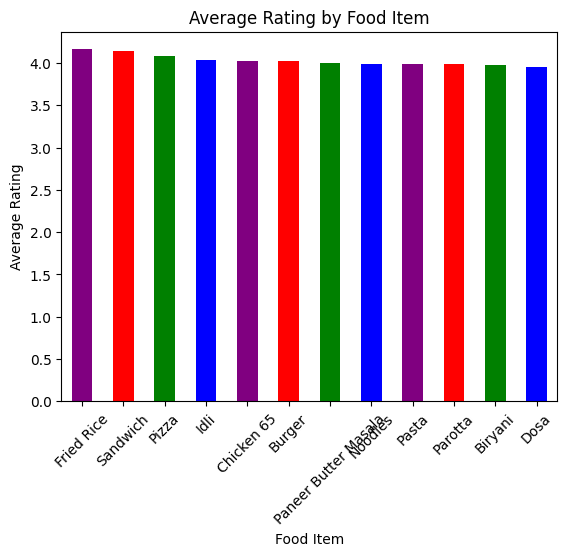

In [ ]:
import matplotlib.pyplot as plt

food_rating = df.groupby('FoodItem')['CustomerRating'].mean().sort_values(ascending=False)

food_rating.plot(kind='bar' ,color=['purple','red','green','blue'])
plt.title('Average Rating by Food Item')
plt.xlabel('Food Item')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

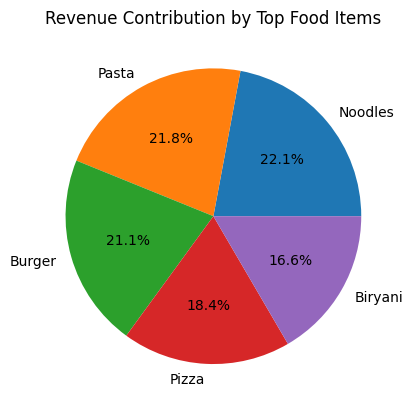

In [ ]:
import matplotlib.pyplot as plt

df['Revenue'] = df['Quantity'] * df['Price']
revenue_by_food = df.groupby('FoodItem')['Revenue'].sum().sort_values(ascending=False).head(5)

revenue_by_food.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue Contribution by Top Food Items')
plt.ylabel('')
plt.show()

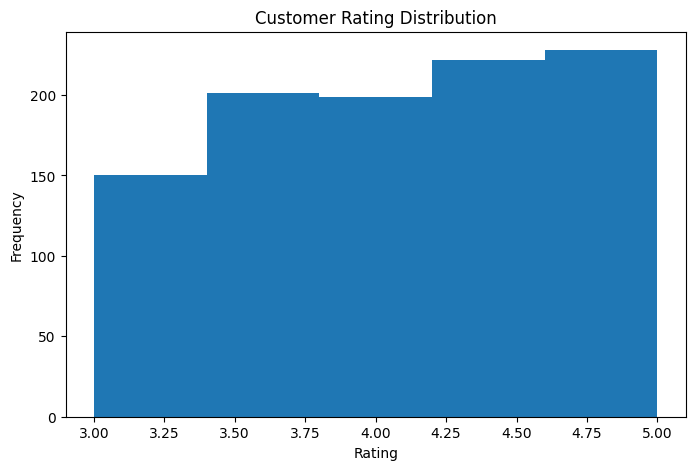

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['CustomerRating'], bins=5)
plt.title('Customer Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

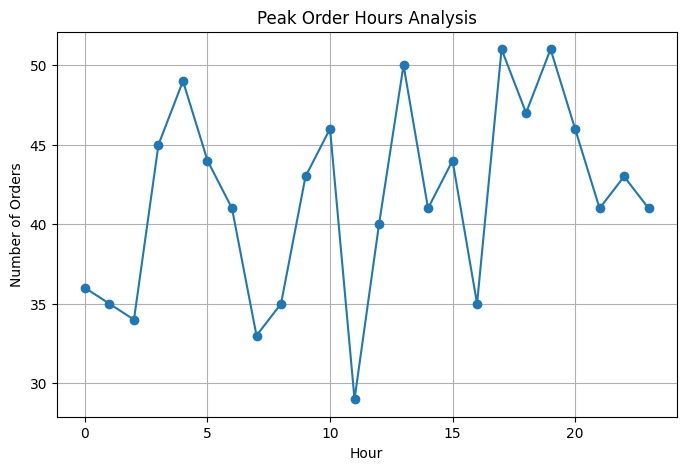

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset into df (assuming it's not already loaded in the current session after a cell deletion)
df = pd.read_csv('/content/food_delivery_data.csv')

# Convert 'OrderTime' to datetime objects and calculate peak_hours
df['OrderTime'] = pd.to_datetime(df['OrderTime'], format='%H:%M')
peak_hours = df.groupby(df['OrderTime'].dt.hour)['OrderID'].count()

plt.figure(figsize=(8,5))
peak_hours.plot(kind='line', marker='o')
plt.title('Peak Order Hours Analysis')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.show()

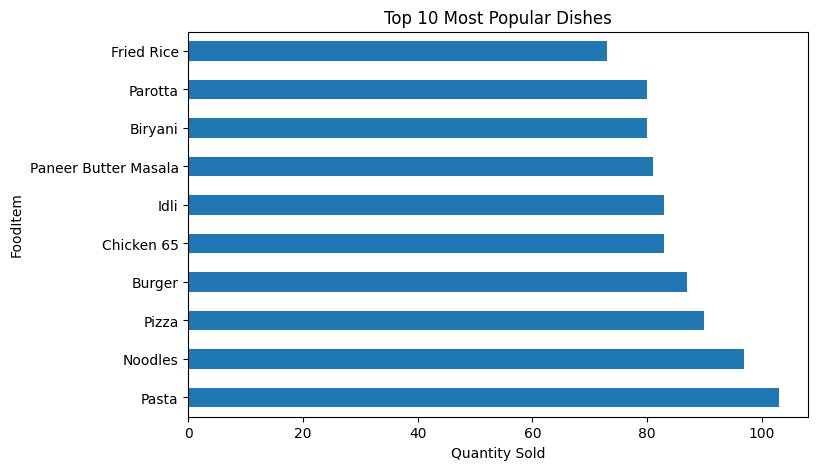

In [10]:
import matplotlib.pyplot as plt

# Ensure popular_dishes is defined
popular_dishes = df['FoodItem'].value_counts()

plt.figure(figsize=(8,5))
popular_dishes.head(10).plot(kind='barh')
plt.title('Top 10 Most Popular Dishes')
plt.xlabel('Quantity Sold')
plt.show()

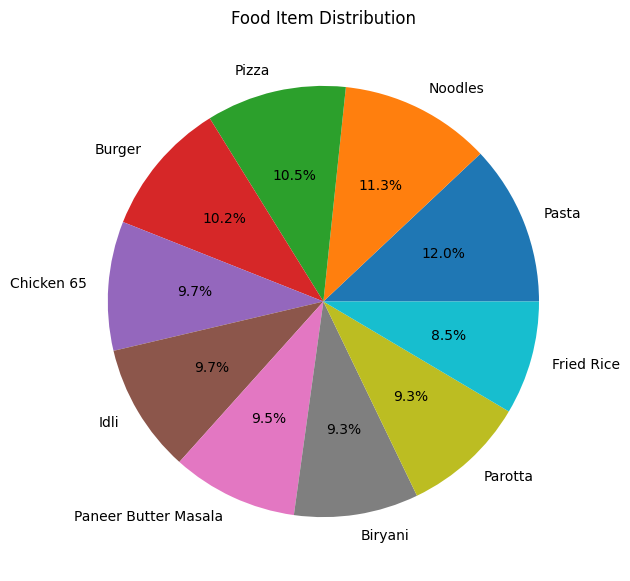

In [11]:
plt.figure(figsize=(7,7))
df['FoodItem'].value_counts().head(10).plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Food Item Distribution')
plt.ylabel('')
plt.show()